## Research Questions 

# Question - 1
# Does the duration of the video influence the views and comments?

In [191]:
# Import all the necessary libraries for data manipulation and file handling
import pandas as pd 

from pathlib import Path 
# Load the Clean data into a pandas DataFrame from the specified CSV file located in the "processed files" directory
input_file_path = Path.cwd().parent / "processed files" / "netflix_india_yt_data.csv"

df = pd.read_csv(input_file_path)
# Display First Five Rows   
df.head(5)

,video_id,content_theme,published_date,like_count,view_count,comment_count,tags_count,duration_minutes,video_length_bucket,title_length,weekday,comment_rate,like_rate
0,KQ2a4uawQBo,Other,2024-12-20,7111.0,52864,394.0,19,1.18,Short,81,Friday,0.75,13.45
1,bOR7S0j_wq8,Other,2024-12-19,642.0,44300,30.0,23,3.03,Short,90,Thursday,0.07,1.45
2,GRM8Q-1fVJ0,Teaser,2024-12-19,3300.0,201087,101.0,30,1.25,Short,96,Thursday,0.05,1.64
3,b0b8WBglCHo,Teaser,2024-12-18,354.0,19642,25.0,20,1.73,Short,53,Wednesday,0.13,1.80
4,QCPOl_7cdnQ,Teaser,2024-12-18,3455.0,117292,130.0,20,1.68,Short,61,Wednesday,0.11,2.95


## Part 1 :
Check for correlation between video duration minutes and view_count.

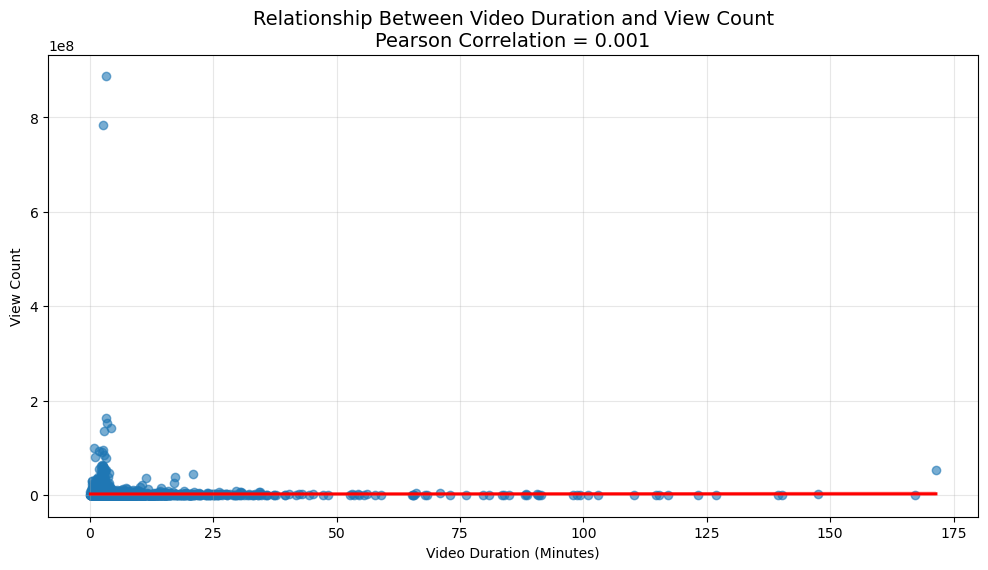

In [192]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.regplot(
    data=df,
    x="duration_minutes",
    y="view_count",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)

correlation = df["duration_minutes"].corr(df["view_count"])

plt.title(
    f"Relationship Between Video Duration and View Count\nPearson Correlation = {correlation:.3f}",
    fontsize=14
)

plt.xlabel("Video Duration (Minutes)")
plt.ylabel("View Count")

plt.grid(alpha=0.3)

plt.show()

In [193]:
df['duration_minutes'].corr(df['view_count'])

0.0012060819960026219

In [194]:
df['duration_minutes'].min() , df['duration_minutes'].max()

(0.12, 171.42)

In [195]:
df['view_count'].min() , df['view_count'].max()

(1725, 888330690)

In [196]:
# Create a new column 'video_duration_bucket' in the DataFrame 
# to categorize videos based on their duration into specific time buckets
import numpy as np

conditions =[
    (df['duration_minutes'] > 0) & (df['duration_minutes'] <= 3),
    (df['duration_minutes'] > 3 ) & (df['duration_minutes'] <= 10),
    (df['duration_minutes'] > 10 ) & (df['duration_minutes'] <= 30),
    (df['duration_minutes'] > 30 ) & (df['duration_minutes'] <= 60),
    (df['duration_minutes'] > 60)
]

values = [
    '(0-3) Minutes',
    '(4-10) Minutes',
    '(11-30) Minutes',
    '(31-60) Minutes',
    '60+ Minutes'
]

df['video_duration_bucket'] = np.select(
    condlist = conditions,
    choicelist = values,
    default = pd.NA
)

In [197]:
video_view_df = df.groupby(by = 'video_duration_bucket')['view_count'].mean().reset_index()

video_view_df.columns = ['video_duration_bucket' , 'avg_view_count']

video_view_df['avg_view_count'] = round(video_view_df['avg_view_count'] , 2)

video_view_df.sort_values(by = 'avg_view_count' , ascending = False)


,video_duration_bucket,avg_view_count
3,(4-10) Minutes,2684304.27
0,(0-3) Minutes,2070291.82
4,60+ Minutes,1917421.61
1,(11-30) Minutes,1668927.04
2,(31-60) Minutes,1343713.24


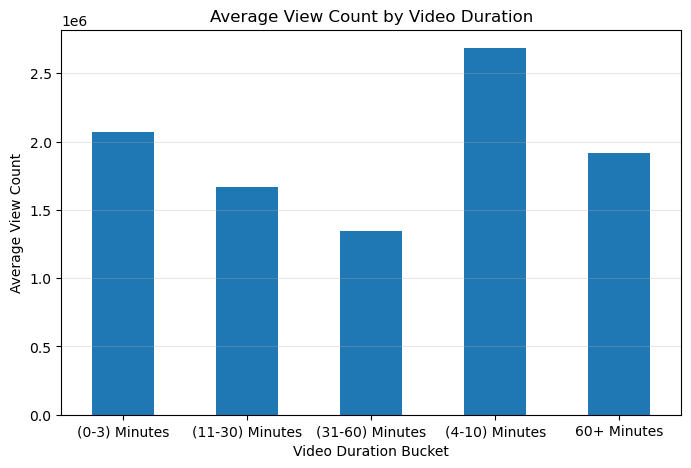

In [198]:
import matplotlib.pyplot as plt

video_view_df.plot.bar(
    x="video_duration_bucket",
    y="avg_view_count",
    legend=False,
    figsize=(8, 5)
)

plt.title("Average View Count by Video Duration")
plt.xlabel("Video Duration Bucket")
plt.ylabel("Average View Count")
plt.grid(alpha=0.3 , axis ='y')
plt.xticks(rotation=0)

plt.show()

## Answer : 
Although the overall relationship is negligible, videos between 4 and 10 minutes achieve the highest average view count (2.68 million views), followed by videos between 0 and 3 minutes (2.07 million views). 

This indicates that short to medium-length videos tend to attract more viewers than longer videos on the Netflix India YouTube channel.

## Part 2 :
Check for Correlation between Video duration minutes and comment_count.

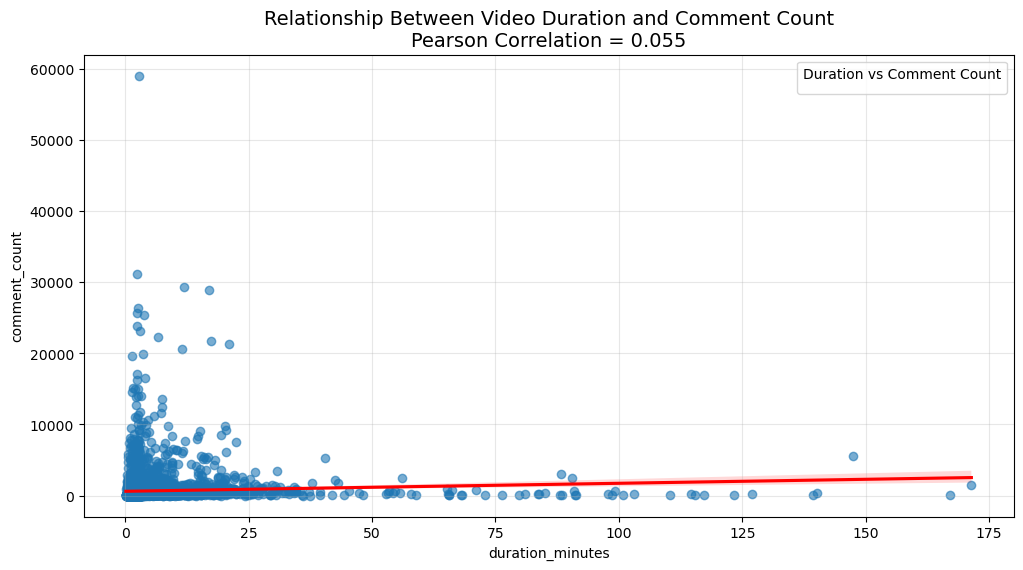

In [199]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (12 , 6))

correlation = df['duration_minutes'].corr(df['comment_count'])

plt.title(
    f"Relationship Between Video Duration and Comment Count\nPearson Correlation = {correlation:.3f}",
    fontsize=14
)

plt.xlabel('Video Duration in Minutes')

plt.ylabel('Comment Count')

plt.legend(
    title = 'Duration vs Comment Count',
    loc = 'upper right',
    labels = ['Duration vs Comment Count']
)

sns.regplot(data = df , x = 'duration_minutes' , y = 'comment_count' , scatter_kws = {'alpha' : 0.6} , line_kws = {'color' : 'red'})

plt.grid(alpha = 0.3)

plt.show()

In [200]:
video_comment_df = df.groupby(by = 'video_duration_bucket')['comment_count'].mean().reset_index()

video_comment_df.columns = ['video_duration_bucket' , 'avg_comment_count']

video_comment_df['avg_comment_count'] = round(video_comment_df['avg_comment_count'] , 0)

video_comment_df.sort_values(by = 'avg_comment_count' , ascending = False)

,video_duration_bucket,avg_comment_count
1,(11-30) Minutes,1379.0
3,(4-10) Minutes,833.0
2,(31-60) Minutes,778.0
4,60+ Minutes,529.0
0,(0-3) Minutes,523.0


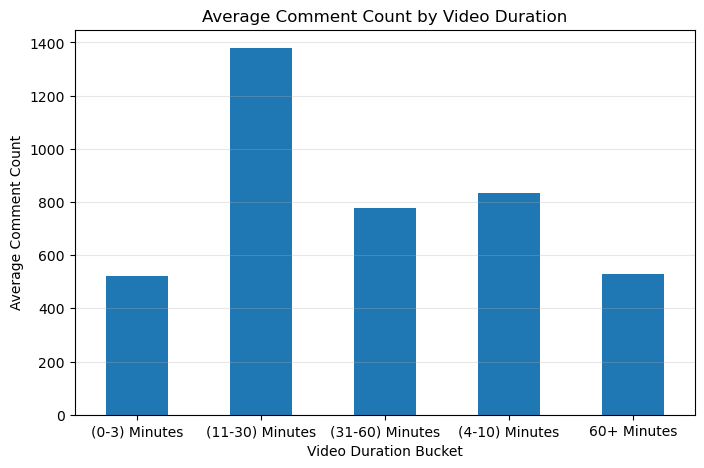

In [201]:
import matplotlib.pyplot as plt 
video_comment_df.plot.bar(
    x = 'video_duration_bucket',    
    y = 'avg_comment_count',
    legend = False, 
    figsize = (8 , 5)
) 

plt.title("Average Comment Count by Video Duration")
plt.xlabel("Video Duration Bucket") 
plt.ylabel("Average Comment Count")
plt.grid(alpha = 0.3 , axis = 'y')
plt.xticks(rotation = 0)    
plt.show()


In [202]:
df['duration_minutes'].corr(df['comment_count'])

0.05522768244836872

In [203]:
df['comment_count'].min() , df['comment_count'].max()

(0.0, 59038.0)

## Answer :
Despite the weak overall relationship, videos with a duration of 11-30 minutes received the highest average number of comments (1,379 comments per video), outperforming both shorter and longer videos , suggesting that medium-length content may encourage relatively more audience discussion.

# Question - 2
#  Is there a relation between the views and comments?

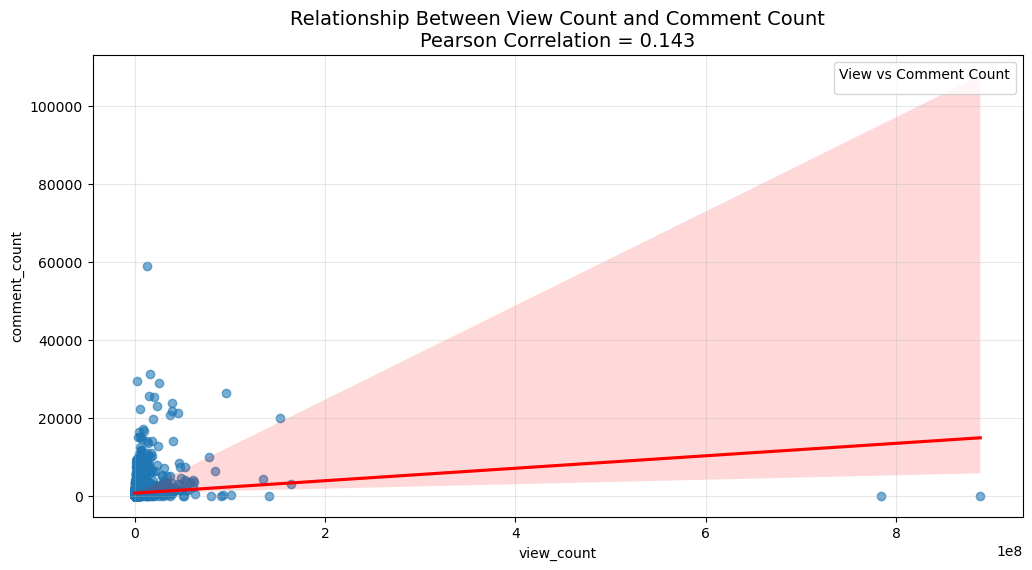

In [204]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (12 , 6))

correlation = df['view_count'].corr(df['comment_count'])

plt.title(
    f"Relationship Between View Count and Comment Count\nPearson Correlation = {correlation:.3f}",
    fontsize=14
)

plt.xlabel('View Count')

plt.ylabel('Comment Count')

plt.legend(
    title = 'View vs Comment Count',
    loc = 'upper right',
    labels = ['View vs Comment Count']
)

sns.regplot(data = df , x = 'view_count' , y = 'comment_count' , scatter_kws = {'alpha' : 0.6} , line_kws = {'color' : 'red'})

plt.grid(alpha = 0.3)

plt.show()

In [205]:
df['view_count'].corr(df['comment_count'])

0.14252440159454058

# Answer : 
A weak positive correlation (r = 0.143) was observed between view count and comment count, indicating that videos with higher view counts tend to receive slightly more comments. However, the relationship is weak, suggesting that audience discussion is influenced by factors beyond the number of views, such as content type, emotional appeal, audience engagement, and the nature of the video.

# Question - 3 
#  Does tag count matter to get more views?

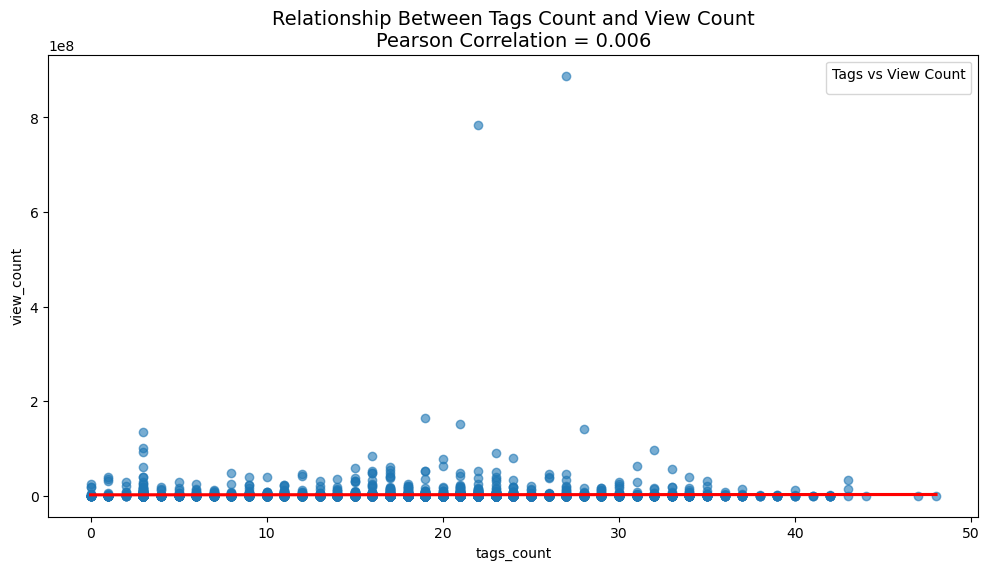

In [206]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (12 , 6))

correlation = df['tags_count'].corr(df['view_count'])

plt.title(
    f"Relationship Between Tags Count and View Count\nPearson Correlation = {correlation:.3f}",
    fontsize=14
)

plt.xlabel('Tags Count')

plt.ylabel('View Count')

plt.legend(
    title = 'Tags vs View Count',
    loc = 'upper right',
    labels = ['Tags vs View Count']
)

sns.regplot(data = df , x = 'tags_count' , y = 'view_count' , scatter_kws = {'alpha' : 0.6} , line_kws = {'color' : 'red'})

plt.show()

In [207]:
df['tags_count'].corr(df['view_count'])

0.006200213777237889

In [208]:
df['tags_count'].min() , df['tags_count'].max()

(0, 48)

In [209]:
import numpy as  np

conditions = [
    (df['tags_count'] >= 0 ) & (df['tags_count'] <= 10),
    (df['tags_count'] > 10 ) & (df['tags_count'] <= 20),
    (df['tags_count'] > 20)  & (df['tags_count'] <= 30),
    (df['tags_count'] > 30)
]

values = [
    '(0-10) Tags',
    '(11-20) Tags',
    '(21-30) Tags',
    '30+ Tags'
]

df['tags_bucket'] = np.select(
    condlist= conditions,
    choicelist = values,
    default = pd.NA
) 

In [210]:
video_tags_view_df = df.groupby(by = 'tags_bucket')['view_count'].mean().reset_index()

video_tags_view_df.columns = ['tags_bucket' , 'avg_view_count']

video_tags_view_df['avg_view_count'] = round(video_tags_view_df['avg_view_count'] , 2)

video_tags_view_df.sort_values(by = 'avg_view_count' , ascending = False)

,tags_bucket,avg_view_count
2,(21-30) Tags,2556430.88
3,30+ Tags,2450223.29
0,(0-10) Tags,2218693.23
1,(11-20) Tags,1738300.93


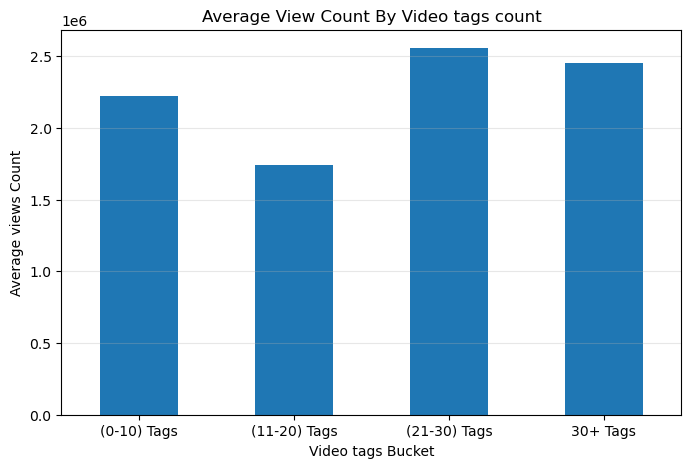

In [211]:
import matplotlib.pyplot as plt 
video_tags_view_df.plot.bar(
    x = 'tags_bucket',    
    y = 'avg_view_count',
    legend = False, 
    figsize = (8 , 5)
) 

plt.title("Average View Count By Video tags count")
plt.xlabel("Video tags Bucket") 
plt.ylabel("Average views Count")
plt.grid(alpha = 0.3 , axis = 'y')
plt.xticks(rotation = 0)    
plt.show()

# Answer :
Tag count does not appear to have a meaningful influence on video views. The Pearson correlation coefficient between tag count and view count is 0.006, indicating virtually no linear relationship. Although videos with 21-30 tags recorded the highest average view count (2.56 million), the differences across tag buckets are inconsistent, suggesting that simply adding more tags does not guarantee higher viewership.

# Question 4 :
#  Does video publishing day or time influence the engagement?

In [212]:
df1 = df.groupby(by = 'weekday')['view_count'].mean().reset_index()

df1.columns = ['weekday' , 'avg_views_count']

df1['avg_views_count'] = round(df1['avg_views_count'] , 2)

df1.sort_values(by = 'avg_views_count' , ascending = False)

,weekday,avg_views_count
6,Wednesday,3020295.05
2,Saturday,2764334.21
1,Monday,2446806.52
5,Tuesday,2193941.80
0,Friday,2140306.23
4,Thursday,1358148.25
3,Sunday,1210702.58


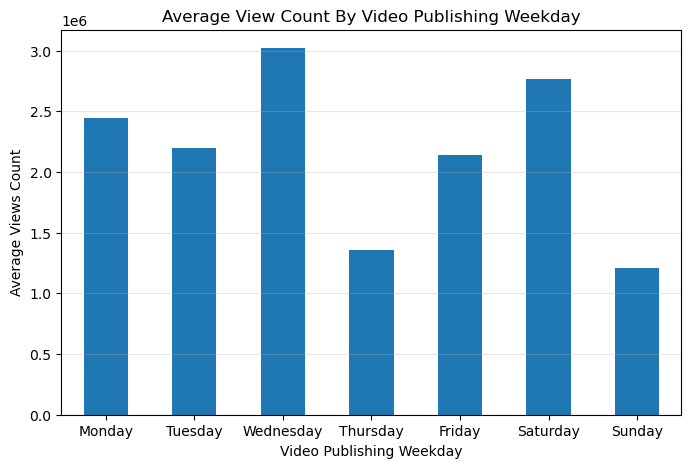

In [213]:
weekday_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

df1['weekday'] = pd.Categorical(
    df1['weekday'],
    categories=weekday_order,
    ordered=True
)

df1 = df1.sort_values('weekday')

df1.plot.bar(
    x='weekday',
    y='avg_views_count',
    legend=False,
    figsize=(8, 5)
)

plt.title("Average View Count By Video Publishing Weekday")
plt.xlabel("Video Publishing Weekday")
plt.ylabel("Average Views Count")
plt.grid(alpha=0.3, axis='y')
plt.xticks(rotation=0)

plt.show()

# Answer :
Yes , Video Publishing Day Influence video engagement and views Count.
Videos Published in Wednesday got more views and engagement followed by Saturday and Monday on an average.

# Question 5 : Findout Popular Youtube Videos in Netflix India Youtube Channel

In [214]:
median_view_count = df.describe()['view_count']['50%']

median_comment_count = df.describe()['comment_count']['50%']

median_like_count = df.describe()['like_count']['50%']

In [215]:
netflix_popular_video_df = df[(df['view_count'] > median_view_count) & (df['like_count'] > median_like_count) & (df['comment_count'] > median_comment_count)]

len(netflix_popular_video_df)

2075

In [216]:
netflix_popular_video_df.head(5)

,video_id,content_theme,published_date,like_count,view_count,comment_count,tags_count,duration_minutes,video_length_bucket,title_length,weekday,comment_rate,like_rate,video_duration_bucket,tags_bucket
7,OEKlIWfjgxs,Other,2024-12-17,12031.0,407963,324.0,26,8.20,Short,93,Tuesday,0.08,2.95,(4-10) Minutes,(21-30) Tags
11,IsQOfF7Hft0,Other,2024-12-16,121455.0,16376809,2173.0,5,3.23,Short,85,Monday,0.01,0.74,(4-10) Minutes,(0-10) Tags
14,86HQHDZLs7Y,Other,2024-12-14,119509.0,2555476,578.0,11,0.85,Short,71,Saturday,0.02,4.68,(0-3) Minutes,(11-20) Tags
15,nODPA-8vc_w,Comedy,2024-12-14,26761.0,2050569,417.0,16,2.30,Short,56,Saturday,0.02,1.31,(0-3) Minutes,(11-20) Tags
18,aw7aOjvGbdc,Interview,2024-12-13,6897.0,307116,364.0,13,12.08,Long,86,Friday,0.12,2.25,(11-30) Minutes,(11-20) Tags


In [217]:
unpopular_netflix_video_df = df[~ df['video_id'].isin(netflix_popular_video_df['video_id'].tolist())]

## What do these popular videos have in common?

# 1).Compare Average Duration of Popular Videos with Average Duration of Unpopular Videos in the dataset.

In [218]:
unpopular_netflix_video_df['duration_minutes'].mean() , netflix_popular_video_df['duration_minutes'].mean()

(3.499603148573303, 5.975156626506023)

In [219]:
if unpopular_netflix_video_df['duration_minutes'].mean() > netflix_popular_video_df['duration_minutes'].mean():
    print("The average duration of all unpopular videos is longer than that of popular videos.")
else:
    print("The average duration of popular videos is longer than that of all unpopular videos.")

The average duration of popular videos is longer than that of all unpopular videos.


# 2). Compare Average Tags Count of Popular Videos with Average Tags Count of all Unpopular Videos in the dataset.

In [220]:
unpopular_netflix_video_df['tags_count'].mean() , netflix_popular_video_df['tags_count'].mean()

(18.265988848802888, 18.41012048192771)

In [221]:
if unpopular_netflix_video_df['tags_count'].mean() > netflix_popular_video_df['tags_count'].mean():
    print("The average tags count of all unpopular videos is higher than that of popular videos.")
else:
    print("The average tags count of popular videos is higher than that of all unpopular videos.")

The average tags count of popular videos is higher than that of all unpopular videos.


## Compare Common tags Between Popular and Unpopular Videos

In [222]:
import pandas as pd
from pathlib import Path
input_file_path  = Path.cwd().parent / "processed files" / "video_tags_list.csv"

video_tags_df = pd.read_csv(input_file_path)

video_tags_df.head(5)

,video_id,video_tags
0,KQ2a4uawQBo,dope shope
1,KQ2a4uawQBo,yo yo honey singh glory
2,KQ2a4uawQBo,yo yo honey singh song
3,KQ2a4uawQBo,yo yo honey singh interview
4,KQ2a4uawQBo,yo yo honey singh news


In [223]:
popular_video_tags = video_tags_df[
    video_tags_df['video_id'].isin(netflix_popular_video_df['video_id'].tolist())
]

In [224]:
len(popular_video_tags)

38204

In [225]:
popular_video_tags.drop_duplicates(keep = 'first'  , inplace = True)

C:\Users\biswa\AppData\Local\Temp\ipykernel_7216\1567897647.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  popular_video_tags.drop_duplicates(keep = 'first'  , inplace = True)


In [226]:
len(popular_video_tags)

38204

In [227]:
popular_video_tags['video_tags'].value_counts( sort = True , ascending = False)

video_tags
netflix           1564
netflix india     1505
netflix shows     1225
bollywood          108
comedy             107
                  ... 
olwen fouéré         1
kim henkel           1
jacob latimore       1
slasher              1
full episodes        1
Name: count, Length: 13732, dtype: int64

In [228]:
unpopular_video_tags = video_tags_df[
    video_tags_df['video_id'].isin(unpopular_netflix_video_df['video_id'].tolist())
]

In [229]:
len(unpopular_video_tags)

55711

In [230]:
unpopular_video_tags['video_tags'].value_counts( sort = True , ascending = False)

video_tags
netflix                     1991
netflix india               1739
netflix shows               1443
netflix movies               162
trailer                      154
                            ... 
aparna balamurali              1
kaapa movie review tamil       1
kaapa trailer hindi            1
malayalam films                1
qaushiq mukherjee              1
Name: count, Length: 18827, dtype: int64

## Question 6 : What is the most used keyword in YT titles? 

In [231]:
video_titles_df = pd.read_csv(Path.cwd().parent / "processed files" / "video_title_keyword.csv")

video_titles_df.head(5)

,video_id,title_list
0,KQ2a4uawQBo,Meet The Real Honey Singh
1,KQ2a4uawQBo,Yo Yo Honey Singh: Famous
2,KQ2a4uawQBo,Watch Now
3,KQ2a4uawQBo,Netflix India
4,bOR7S0j_wq8,Akshay Kumar Almost Gets Caught Cheating! Ft T...


In [232]:
# Top 5 Video Title Keyword used in Netflix India Youtube channel videos
common_video_title_keyword_df =  video_titles_df['title_list'].value_counts(sort = True , ascending= False).reset_index()

common_video_title_keyword_df.nlargest(5 , 'count')

,title_list,count
0,Netflix India,3179
1,Netflix,457
2,Official Trailer,392
3,Official Teaser,89
4,Now Streaming,83


## Answer :
70.94% of Netflix India’s videos use either “Netflix India” (62.04%) or “Netflix” (8.9%) in their titles, indicating a strong and consistent brand-focused titling strategy. 
Among content-related keywords, 'Official Trailer' is used most frequently, highlighting trailers as the channel's dominant promotional format. In contrast, keywords such as 'Official Teaser' and 'Now Streaming' are used less often, suggesting they play a supporting role in the overall content strategy.

## Question 7 : What are the keywords we used the most in tags? 

In [ ]:
# Top Five Common Video Tags in Netflix India Youtube Channel's Videos 
common_video_tags_df =  video_tags_df['video_tags'].value_counts(sort= True , ascending= False).reset_index()

common_video_tags_df.nlargest(5 , 'count')

,video_tags,count
0,netflix,3555
1,netflix india,3244
2,netflix shows,2668
3,trailer,260
4,comedy,249


## Answer :
Netflix India primarily uses brand-focused tags such as 'netflix', 'netflix india', and 'netflix shows' to strengthen brand identity and improve content discoverability. Among descriptive content tags, 'trailer' is the most commonly used, highlighting promotional content as a major part of the channel's publishing strategy. The presence of genre-specific tags like 'comedy' also indicates an effort to improve discoverability for audiences interested in specific types of content.

## Question 8 : What is the frequency of video publishing? 

In [234]:
frequency_video_publishing_df = df.groupby(by = 'weekday')['video_id'].count().reset_index()

frequency_video_publishing_df.columns = ['weekday' , 'video_publishing_frequency']

frequency_video_publishing_df.sort_values(by = 'video_publishing_frequency' , ascending = False)

,weekday,video_publishing_frequency
4,Thursday,802
0,Friday,786
6,Wednesday,776
5,Tuesday,759
1,Monday,706
2,Saturday,670
3,Sunday,625


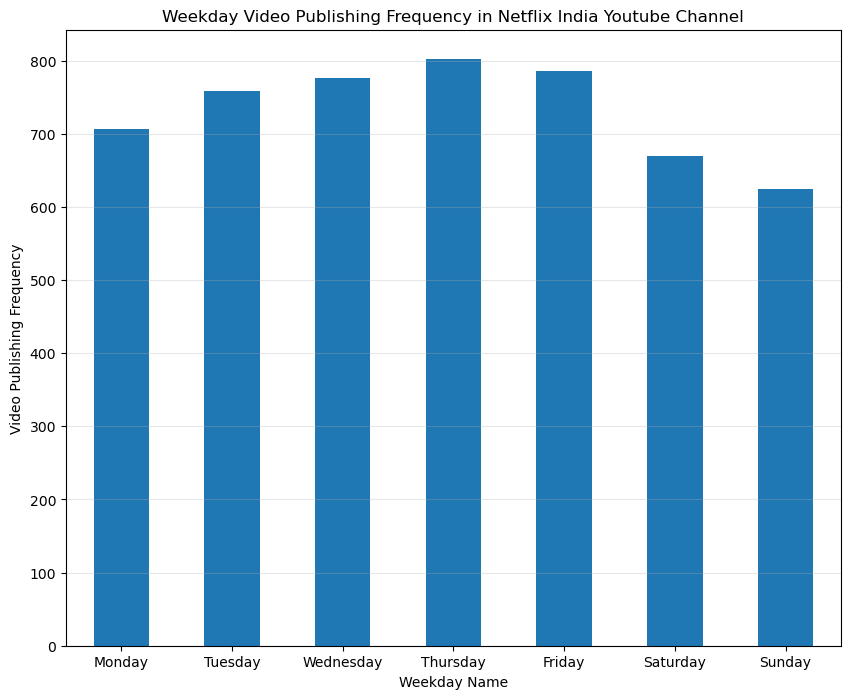

In [235]:
import matplotlib.pyplot as plt 
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

frequency_video_publishing_df["weekday"] = pd.Categorical(
    frequency_video_publishing_df["weekday"],
    categories=weekday_order,
    ordered=True
)

frequency_video_publishing_df = frequency_video_publishing_df.sort_values("weekday")

frequency_video_publishing_df.plot.bar( x = 'weekday' , y = 'video_publishing_frequency' , legend = False , figsize = (10 , 8))

plt.title("Weekday Video Publishing Frequency in Netflix India Youtube Channel")
plt.xlabel("Weekday Name")

plt.ylabel("Video Publishing Frequency")

plt.xticks(rotation = 0)

plt.grid(alpha = 0.3 , axis = 'y' )

plt.show()


## Answer :
Netflix India follows a consistent weekly video publishing strategy, releasing content across all seven days of the week. Although videos are uploaded throughout the week, Thursday records the highest publishing frequency, while Sunday has the fewest uploads. The relatively small differences between weekdays indicate that the channel prioritizes maintaining a steady flow of content rather than relying on a single publishing day.

## Question 9 : Are there any videos that have no tags, but performed well?

In [236]:
df[
    (df['tags_count'] == 0) 
    & 
    (df['view_count'] > median_view_count) 
    & 
    (df['comment_count'] > median_comment_count)
     &
    (df['like_count'] > median_like_count) 
]

,video_id,content_theme,published_date,like_count,view_count,comment_count,tags_count,duration_minutes,video_length_bucket,title_length,weekday,comment_rate,like_rate,video_duration_bucket,tags_bucket
4984,5D44xtgZlv8,Other,2018-09-24,41185.0,18407319,1823.0,0,0.85,Short,41,Monday,0.01,0.22,(0-3) Minutes,(0-10) Tags
5005,Kwqayc6tDPY,Teaser,2018-08-03,40118.0,18523444,2379.0,0,1.00,Short,37,Friday,0.01,0.22,(0-3) Minutes,(0-10) Tags
5040,asxx8fnzjBQ,Other,2018-04-02,26609.0,24051981,2410.0,0,0.52,Short,20,Monday,0.01,0.11,(0-3) Minutes,(0-10) Tags


## Answer :
The analysis identified three videos with no tags that still exceeded the median view, like, and comment counts. This demonstrates that tags are not essential for achieving strong performance on the Netflix India YouTube channel. The findings suggest that content quality, brand recognition, titles, thumbnails, and audience interest have a greater impact on video success than the presence of tags alone.

## Question 10 : What is our views distribution (consider all the videos)

In [237]:
# Descriptive Statistics for View Count in Netflix India Youtube Channel's Videos
df['view_count'].describe()

count    5.124000e+03
mean     2.169536e+06
std      1.807395e+07
min      1.725000e+03
25%      5.906175e+04
50%      2.210810e+05
75%      9.373165e+05
max      8.883307e+08
Name: view_count, dtype: float64

In [238]:
# Measure the skewness of the view count distribution in Netflix India Youtube Channel's Videos
df['view_count'].skew()

39.57644716471513

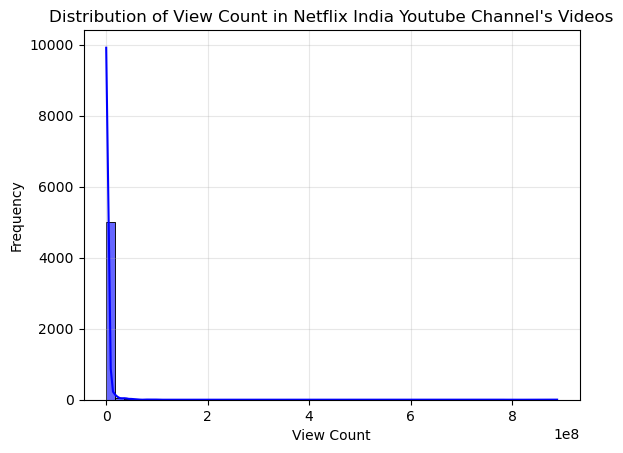

In [239]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data = df , x = 'view_count' , bins = 50 , kde = True , color = 'blue' , alpha = 0.6)
plt.title("Distribution of View Count in Netflix India Youtube Channel's Videos")
plt.xlabel("View Count")
plt.ylabel("Frequency")
plt.grid(alpha = 0.3)
plt.show()

## Answer :
The analysis shows that view counts on the Netflix India YouTube channel are highly concentrated among a small number of viral videos. The distribution is extremely right-skewed (skewness = 39.58), with the average view count (2.17 million) being much higher than the median (221,081). Furthermore, 75% of videos receive fewer than 937,317 views, indicating that only a limited number of videos achieve exceptionally high reach. These findings suggest that the median provides a more reliable measure of typical video performance than the mean.

## Question 11 : Does title length influence views? 


In [240]:
df['title_length'].corr(df['view_count'])

0.004811879184394402

In [241]:
df['title_length'].max() , df['title_length'].min()

(120, 11)

In [242]:
df['title_length'].describe()

count    5124.000000
mean       73.507611
std        18.009707
min        11.000000
25%        60.000000
50%        76.000000
75%        89.000000
max       120.000000
Name: title_length, dtype: float64

In [243]:
df['title_length'].value_counts()

title_length
92     140
93     138
95     127
91     124
89     116
      ... 
24       1
113      1
12       1
11       1
109      1
Name: count, Length: 95, dtype: int64

In [244]:
import numpy as np

conditions = [
    (df['title_length'] >= 11) & (df['title_length'] <= 30) ,
    (df['title_length'] >= 31) & (df['title_length'] <= 50),
    (df['title_length'] >= 51) & (df['title_length'] <= 70),
    (df['title_length'] >= 71) & (df['title_length'] <= 90),
    (df['title_length'] >= 91)
]

values = [
    '11-30',
    '31-50',
    '51-70',
    '71-90',
    '90+'
]

df['title_length_bucket'] = np.select(
    condlist= conditions,
    choicelist= values,
    default = pd.NA
)

In [245]:
title_length_df =  df.groupby(by = 'title_length_bucket')['view_count'].mean().reset_index()

title_length_df.columns = ['title_length_bucket' , 'avg_view_count']

title_length_df['avg_view_count'] = round(title_length_df['avg_view_count'] , 2)

title_length_df.sort_values(by = 'avg_view_count' , ascending = False)

,title_length_bucket,avg_view_count
2,51-70,2458573.99
4,90+,2423850.81
0,11-30,2211491.50
3,71-90,2023517.72
1,31-50,1468186.82


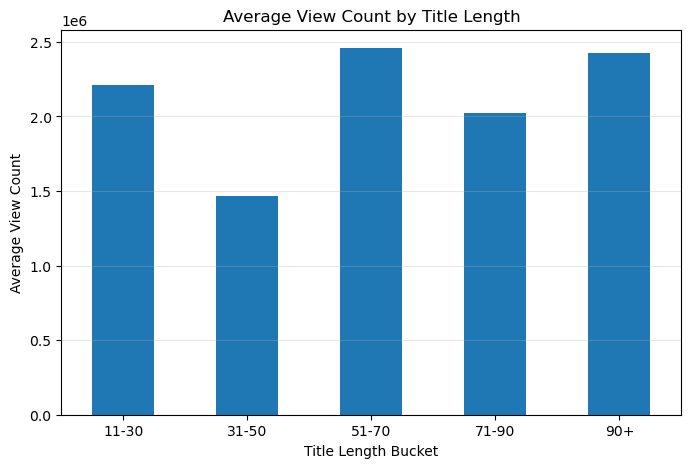

In [246]:
import matplotlib.pyplot as plt
title_length_df.plot.bar(
    x = 'title_length_bucket',  
    y = 'avg_view_count',
    legend = False,
    figsize = (8 , 5)
)   

plt.title("Average View Count by Title Length")

plt.xlabel("Title Length Bucket")

plt.ylabel("Average View Count")
plt.grid(alpha = 0.3 , axis = 'y')
plt.xticks(rotation = 0)
plt.show()

## Answer :
The analysis found virtually no relationship between title length and video views (Pearson's r = 0.004). Although videos with titles between 51 and 70 characters recorded the highest average view count, the differences across title-length buckets were inconsistent. This suggests that title length alone is not a reliable driver of video performance, and other factors such as content relevance, thumbnails, and audience interest are likely to play a more significant role in attracting viewers.

## Question 12 : Are there certain topics or themes that consistently perform better than others?

In [247]:
df.head()

,video_id,content_theme,published_date,like_count,view_count,comment_count,tags_count,duration_minutes,video_length_bucket,title_length,weekday,comment_rate,like_rate,video_duration_bucket,tags_bucket,title_length_bucket
0,KQ2a4uawQBo,Other,2024-12-20,7111.0,52864,394.0,19,1.18,Short,81,Friday,0.75,13.45,(0-3) Minutes,(11-20) Tags,71-90
1,bOR7S0j_wq8,Other,2024-12-19,642.0,44300,30.0,23,3.03,Short,90,Thursday,0.07,1.45,(4-10) Minutes,(21-30) Tags,71-90
2,GRM8Q-1fVJ0,Teaser,2024-12-19,3300.0,201087,101.0,30,1.25,Short,96,Thursday,0.05,1.64,(0-3) Minutes,(21-30) Tags,90+
3,b0b8WBglCHo,Teaser,2024-12-18,354.0,19642,25.0,20,1.73,Short,53,Wednesday,0.13,1.80,(0-3) Minutes,(11-20) Tags,51-70
4,QCPOl_7cdnQ,Teaser,2024-12-18,3455.0,117292,130.0,20,1.68,Short,61,Wednesday,0.11,2.95,(0-3) Minutes,(11-20) Tags,51-70


In [248]:
df['content_theme'].value_counts()

content_theme
Other                3055
Teaser                906
Clip                  248
Comedy                181
Action                174
Romance               169
Announcement          139
Song                   82
Interview              80
Drama                  41
Behind the Scenes      29
Horror                 20
Name: count, dtype: int64

In [ ]:
theme_performance_df = df.groupby(by = 'content_theme').aggregate({'view_count' : 'mean' , 'comment_count' : 'mean' , 'like_count' : 'mean'}).reset_index()

theme_performance_df.columns = ['content_theme' , 'avg_view_count' , 'avg_comment_count' , 'avg_like_count']

theme_performance_df['avg_view_count'] = round(theme_performance_df['avg_view_count'] , 2)

theme_performance_df['avg_comment_count'] = round(theme_performance_df['avg_comment_count'] , 2)

theme_performance_df['avg_like_count'] = round(theme_performance_df['avg_like_count'] , 2)

theme_performance_df.sort_values(by = 'avg_view_count' , ascending = False)

,content_theme,avg_view_count,avg_comment_count,avg_like_count
10,Song,5284562.09,1200.96,60391.44
11,Teaser,3893686.07,1159.91,32764.37
0,Action,2604711.10,617.53,26248.61
3,Clip,1859710.05,410.23,16987.62
8,Other,1764421.51,529.74,24771.08
4,Comedy,1648892.11,523.23,32621.44
9,Romance,1389433.20,284.17,14089.50
6,Horror,1233718.40,1139.75,38772.25
7,Interview,1167880.58,528.69,30830.55
1,Announcement,1047974.75,959.88,22505.47


## Answer : 
The analysis shows that video performance varies considerably across content themes. Song videos are the highest-performing category, followed by Teasers, both generating substantially higher average views, likes, and comments than most other themes. In contrast, categories such as Drama and Behind the Scenes attract comparatively lower audience engagement. These findings suggest that content theme is an important factor influencing video performance, with promotional and music-related content consistently outperforming many other formats on the Netflix India YouTube channel.
